# Imports and definitions

In [1]:
import os
import sys
import json
import argparse
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns

from glob import glob
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import threshold_img, resample_to_img, binarize_img
from nilearn.glm import threshold_stats_img

In [2]:
from nilearn.masking import apply_mask
from scipy import stats

In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

In [65]:
pd.set_option("display.float_format", '{:.4f}'.format)

In [4]:
from nilearn import plotting, datasets, surface

# for plotting slices
mni152_template = datasets.load_mni152_template(resolution=1)
# for plotting on surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


In [5]:
task_label = 'badaga'
fwhm = 6.00
space_label = 'MNI152NLin2009cAsym'

# define data directories
bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 
                        'SSP/',
                        'data_bids'
                       )
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')
masks_dir = os.path.join(nilearn_dir, 'masks')
# define first-level directory where group-level inputs will be pulled from
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')

# create output directory
group_out_dir = os.path.join(nilearn_dir, 'group_fwhm-%.02f'%fwhm)
if not os.path.exists(group_out_dir):
        os.makedirs(group_out_dir)

In [6]:
bidsroot

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids'

In [7]:
contrast_list = ['q',  '8', '0', 'n2', 'n6'] # '8', 'n2', 
network_list  = ['auditory', 'tian_subcortical_S2']

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [22]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-SSP001', 'sub-SSP002',
               'sub-SSP005', 'sub-SSP012',
               'sub-SSP014', 
               'sub-SSP069', 'sub-SSP072', 
               'sub-SSP076', # missing MRI files
               'sub-SSP102', # participant left after a few minutes
               'sub-SSP098', 'sub-SSP105', 'sub-SSP106', 'sub-SSP107', # currently processing
               ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [23]:
print(participants_df)

   participant_id  age sex    group
0      sub-SSP008    9   M  control
1      sub-SSP009    9   M  control
2      sub-SSP011   11   M  control
3      sub-SSP013   11   M  control
4      sub-SSP015   10   M  control
5      sub-SSP017   11   M  control
6      sub-SSP018    8   F      CWS
7      sub-SSP020   13   F      CWS
8      sub-SSP021    8   M      CWS
9      sub-SSP028   10   M  control
10     sub-SSP032   12   M  control
11     sub-SSP033    7   F  control
12     sub-SSP034    9   F  control
13     sub-SSP036   11   M  control
14     sub-SSP038    9   M  control
15     sub-SSP039   12   M  control
16     sub-SSP040    9   F  control
17     sub-SSP041   11   M  control
18     sub-SSP045   10   M      CWS
19     sub-SSP046   10   M      CWS
20     sub-SSP048    9   M      CWS
21     sub-SSP051    8   F  control
22     sub-SSP054   12   F  control
23     sub-SSP056    8   F  control
24     sub-SSP058    7   F      CWS
25     sub-SSP060    8   M  control
26     sub-SSP062    8   M  

In [24]:
# create group-specific lists of subject IDs
sub_list_cwns = list(participants_df.participant_id[participants_df.group=='control'])
sub_list_cws = list(participants_df.participant_id[participants_df.group=='CWS'])

In [25]:
len(sub_list_cwns)

33

In [26]:
participants_cwns_df = participants_df[participants_df.group=='control'].reset_index(drop=True)
print(participants_cwns_df)

   participant_id  age sex    group
0      sub-SSP008    9   M  control
1      sub-SSP009    9   M  control
2      sub-SSP011   11   M  control
3      sub-SSP013   11   M  control
4      sub-SSP015   10   M  control
5      sub-SSP017   11   M  control
6      sub-SSP028   10   M  control
7      sub-SSP032   12   M  control
8      sub-SSP033    7   F  control
9      sub-SSP034    9   F  control
10     sub-SSP036   11   M  control
11     sub-SSP038    9   M  control
12     sub-SSP039   12   M  control
13     sub-SSP040    9   F  control
14     sub-SSP041   11   M  control
15     sub-SSP051    8   F  control
16     sub-SSP054   12   F  control
17     sub-SSP056    8   F  control
18     sub-SSP060    8   M  control
19     sub-SSP062    8   M  control
20     sub-SSP074   10   M  control
21     sub-SSP077    8   M  control
22     sub-SSP083    9   F  control
23     sub-SSP084   11   M  control
24     sub-SSP085    8   F  control
25     sub-SSP086    8   F  control
26     sub-SSP091   11   M  

In [27]:
len(participants_cwns_df)

33

### Define region dictionary

In [28]:
region_dict = {'auditory': [
                        'L-HG', 'L-PT',  'L-PP', 
                        'L-STGp', 'L-STGa', 
                        'L-ParsOp', 'L-ParsTri',
                        'R-HG', 'R-PT',  'R-PP', 
                        'R-STGp', 'R-STGa', 
                        'R-ParsOp', 'R-ParsTri', 
                          ],
                'tian-S2': [
                    'aCAU-lh',
                    'pCAU-lh',
                    'aPUT-lh',
                    'pPUT-lh',
                    'aCAU-rh',
                    'pCAU-rh',
                    'aPUT-rh',
                    'pPUT-rh',
                    ],

           }
network_list  = list(region_dict.keys())
print('network_list:', network_list)

network_list: ['auditory', 'tian-S2', 'tian-S3']


### define key processing functions

In [29]:
# mask stat maps
def mask_stat_maps(region_list, statmap_dict, masks_dir, network_name, space_label):
    roi_mean_dict = {}
    mask_path_list = []
    
    for rx, region in enumerate(region_list):
        print(region)
        roi_mean_list = []

        for sub_id in statmap_dict:
            stat_fpath = statmap_dict[sub_id]
            if 'tian' in network_name:
                mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
            else:
                mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-*/*{region}*.nii.gz')[0]
            #print(mask_fpath)
            #print(nib.load(mask_fpath).get_fdata().shape)
            
            mask_img = resample_to_img(mask_fpath, stat_fpath, 
                                       interpolation='nearest',
                                       force_resample=True, 
                                       copy_header=True)
            mask_img = binarize_img(mask_img, two_sided=False, copy_header=True)
            masked_data = apply_mask(stat_fpath, mask_img)
            roi_mean_sub = masked_data.mean()
            

            roi_mean_list.append(roi_mean_sub)

        # save mask_fpaths for later
        mask_path_list.append(mask_fpath)
        
        
        roi_mean_dict[region] = roi_mean_list
    
    return roi_mean_dict, mask_path_list

In [30]:
# create ROI dataframe from dictionary
def make_stats_df(roi_mean_dict, participants_df, network_name):
    roi_df = pd.DataFrame.from_dict(roi_mean_dict)

    roi_df['participant_id'] = participants_df.participant_id
    roi_df['participant_group'] = participants_df.group

    roi_df_long = roi_df.melt(id_vars=["participant_id", "participant_group"], 
                              var_name="region", value_name="beta")

    # create new `hemisphere` column
    if network_name == 'auditory':
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[0]
        roi_df_long['region'] = roi_df_long.region.str[2:]
    elif network_name == 'tian_subcortical_S3':
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[-2:]
        roi_df_long['region'] = roi_df_long.region.str[:-3]

    # Filter for non-Mandarin participants
    #stats_df = roi_df_long[roi_df_long['participant_group'] == 'non-Mandarin']
    
    return roi_df_long # stats_df

In [31]:
# plot ROI box plots
def plot_roi_box_plots(stats_df):
    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)
    yrange = [-6, 4.5]

    # Define a color palette
    #palette = ['#e66101', '#5e3c99']  # Example colors, adjust as needed

    # Create the swarm plot with transparent dots
    sns.stripplot(data=stats_df, 
                  x='region', y='beta', 
                  hue='hemisphere',
                  dodge=True,
                  linewidth=0.5,
                  size=3,
                  #alpha=0.6,
                  #palette=palette,  # Use the defined color palette
                  legend=None,
                  ax=ax,
                  zorder=2)  # Lower zorder for the strip plot

    # Make the swarm plot dots transparent
    for collection in ax.collections:
        collection.set_facecolor('none')

    # Create the box plot with colors
    sns.boxplot(data=stats_df, 
                x='region', y='beta', 
                hue='hemisphere',
                dodge=True,
                linewidth=1,
                fliersize=0,
                #palette=palette,  # Use the same color palette
                #legend=None,
                ax=ax,
                zorder=1)  # Higher zorder for the box plot

    #ax.set_ylim(yrange)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_title(f'{contrast_label}')

    # Extend the horizontal dashed line at y=0
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)

    fig.tight_layout()
    
    return fig

In [32]:
# plot ROI-mean values on the brain
# NEED TO UPDATE TO NEW DICTS AND RUN FOR EACH ANALYSIS
def plot_roi_slices(roi_mean_dict, mask_path_list, network_name, space_label, contrast_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    for rx, region in enumerate(roi_mean_dict.region_hemi.unique()): #roi_mean_dict):
        print('region:', region)
        if 'tian' in network_name:
            mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        else:
            mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-*/*{region}*.nii.gz')[0]        #mask_fpath = region
        #roi_img = nib.load(mask_fpath)
        #roi_data = roi_img.get_fdata()
        
        #roi_img = resample_to_img(mask_fpath, stat_fpath, 
        #                           interpolation='nearest',
        #                           force_resample=True, 
        #                           copy_header=True)
        roi_img = binarize_img(mask_fpath, two_sided=False)
        #roi_data = apply_mask(stat_fpath, roi_img)
        roi_data = roi_img.get_fdata()
        
        #roi_stat = np.mean(roi_mean_dict[region])
        roi_stat = roi_mean_dict.loc[roi_mean_dict['region_hemi'] == 'region', 'beta'].mean()
        roi_stat_data = roi_data * roi_stat

        roi_stat_data_list.append(roi_stat_data)

    # add maps together and make nifti img
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    title = f'contrast-{contrast_label}'
    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    fig.suptitle(title);
    
    return fig

# Compare SNRs

## `contrast-snr` for cortical network

In [33]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[0]
print('network_name:', network_name)
statmap_snr_dict = {}
for contrast_label in contrast_list:
    print(contrast_label)
    statmap_single_snr_dict = {}
    for sub_id in sub_list_cwns:
        statmap_single_snr_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}/*contrast-{contrast_label}_stat-effect_statmap.nii.gz'))[0]
    statmap_snr_dict[contrast_label] = statmap_single_snr_dict


network_name: auditory
q
8
0
n2
n6


#### Test plots for a single subject, single ROI

In [34]:
sub_id = 'sub-SSP008'
mask_ex = os.path.join(masks_dir, sub_id, 'space-MNI152NLin2009cAsym/masks-dseg/',
                       f'{sub_id}_space-MNI152NLin2009cAsym_mask-R-PT.nii.gz')
mask_ex_img = nib.load(mask_ex)
print(np.unique(mask_ex_img.get_fdata()))


[0. 1.]


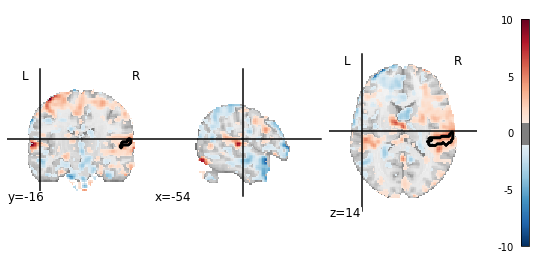

In [35]:
display = plotting.plot_stat_map(statmap_snr_dict['q'][sub_id],
                                  threshold=1, vmax=10,
                                    cut_coords=[-54,-16,14])
display.add_contours(mask_ex, 
                     filled=False, 
                     #levels=[-zthresh, zthresh], 
                     colors=["k", "k"],
                    )

In [36]:
sub_id = 'sub-SSP008'
region = 'R-PT'

stat_fpath = statmap_snr_dict['q'][sub_id]
mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-*/*{region}*.nii.gz')[0]
print(mask_fpath)

mask_img = resample_to_img(mask_fpath, stat_fpath, interpolation='nearest',
                           force_resample=False, copy_header=False)
mask_img = binarize_img(mask_img, two_sided=False)
masked_data = apply_mask(stat_fpath, mask_img)
print(masked_data.mean())

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/masks/sub-SSP008/space-MNI152NLin2009cAsym/masks-dseg/sub-SSP008_space-MNI152NLin2009cAsym_mask-R-PT.nii.gz


/scratch/slurm-7132610/ipykernel_2456187/3865148957.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = resample_to_img(mask_fpath, stat_fpath, interpolation='nearest',
/scratch/slurm-7132610/ipykernel_2456187/3865148957.py:10: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_img = binarize_img(mask_img, two_sided=False)


3.242034066760724


In [37]:
np.unique(nib.load(mask_fpath).get_fdata(), return_counts=True)

(array([0., 1.]), array([778337,    415]))

In [38]:
np.unique(mask_img.get_fdata(), return_counts=True)

(array([0., 1.]), array([599417,    413]))

<Axes: ylabel='Count'>

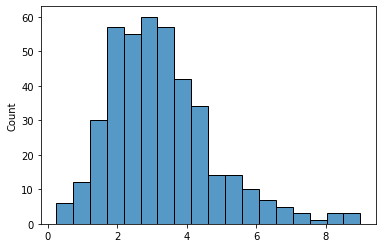

In [39]:
sns.histplot(masked_data)

In [41]:
masked_data.shape

(413,)

#### Create ROI dict

In [42]:
print(f'masking {contrast_label} stat maps for the {network_name} network')

roi_df = {}
for snr in statmap_snr_dict:
    print(f'creating dictionary for {snr}')
    roi_snr_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                                   statmap_snr_dict[snr], 
                                                   masks_dir, 
                                                       network_name,
                                                   space_label)
    roi_df[snr] = roi_snr_mean_dict

masking n6 stat maps for the auditory network
creating dictionary for q
L-HG
L-PT
L-PP
L-STGp
L-STGa
L-ParsOp
L-ParsTri
R-HG
R-PT
R-PP
R-STGp
R-STGa
R-ParsOp
R-ParsTri
creating dictionary for 8
L-HG
L-PT
L-PP
L-STGp
L-STGa
L-ParsOp
L-ParsTri
R-HG
R-PT
R-PP
R-STGp
R-STGa
R-ParsOp
R-ParsTri
creating dictionary for 0
L-HG
L-PT
L-PP
L-STGp
L-STGa
L-ParsOp
L-ParsTri
R-HG
R-PT
R-PP
R-STGp
R-STGa
R-ParsOp
R-ParsTri
creating dictionary for n2
L-HG
L-PT
L-PP
L-STGp
L-STGa
L-ParsOp
L-ParsTri
R-HG
R-PT
R-PP
R-STGp
R-STGa
R-ParsOp
R-ParsTri
creating dictionary for n6
L-HG
L-PT
L-PP
L-STGp
L-STGa
L-ParsOp
L-ParsTri
R-HG
R-PT
R-PP
R-STGp
R-STGa
R-ParsOp
R-ParsTri


In [79]:
roi_dict = {}
for snr in contrast_list: #roi_df.keys():
    snr_df = make_stats_df(roi_df[snr], participants_cwns_df, network_name)
    snr_df['SNR'] = snr
    
    roi_dict[snr] = snr_df
roi_df_long = pd.concat(roi_dict)


# Save the dictionary to a file
with open('roi_df_long.pkl', 'wb') as f:
    pickle.dump(roi_df_long, f)

In [78]:
roi_df.keys()

dict_keys(['q', '8', '0', 'n2', 'n6'])

In [81]:
print(contrast_list)

['q', '8', '0', 'n2', 'n6']


In [75]:
roi_df_long.SNR = pd.Categorical(roi_df_long.SNR, 
                                 categories=contrast_list,
                                ordered=True)

In [83]:
roi_df['q'].keys()

dict_keys(['L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri'])

In [85]:
roi_dict['q'].head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,SNR
0,sub-SSP008,control,HG,1.6207,L-HG,L,q
1,sub-SSP009,control,HG,-0.0383,L-HG,L,q
2,sub-SSP011,control,HG,3.0343,L-HG,L,q
3,sub-SSP013,control,HG,1.5240,L-HG,L,q
4,sub-SSP015,control,HG,2.9838,L-HG,L,q


In [46]:
roi_dict['q'].loc[roi_dict['q'].region_hemi=='L-HG'].head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,SNR
0,sub-SSP008,control,HG,1.620749,L-HG,L,q
1,sub-SSP009,control,HG,-0.038324,L-HG,L,q
2,sub-SSP011,control,HG,3.034295,L-HG,L,q
3,sub-SSP013,control,HG,1.523952,L-HG,L,q
4,sub-SSP015,control,HG,2.983777,L-HG,L,q


In [64]:
np.unique(roi_dict['q'].participant_id).shape

(33,)

#### ROI slice plots - DEBUGGING

region: L-HG


/scratch/slurm-7132610/ipykernel_2456187/336296598.py:21: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  roi_img = binarize_img(mask_fpath, two_sided=False)


region: L-PT
region: L-PP
region: L-STGp
region: L-STGa
region: L-ParsOp
region: L-ParsTri
region: R-HG
region: R-PT
region: R-PP
region: R-STGp
region: R-STGa
region: R-ParsOp
region: R-ParsTri


/scratch/slurm-7132610/ipykernel_2456187/336296598.py:37: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  plotting.plot_stat_map(roi_stat_map_img,
/scratch/slurm-7132610/ipykernel_2456187/336296598.py:37: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  plotting.plot_stat_map(roi_stat_map_img,
/scratch/slurm-7132610/ipykernel_2456187/336296598.py:37: UserWarning: empty mask
  plotting.plot_stat_map(roi_stat_map_img,


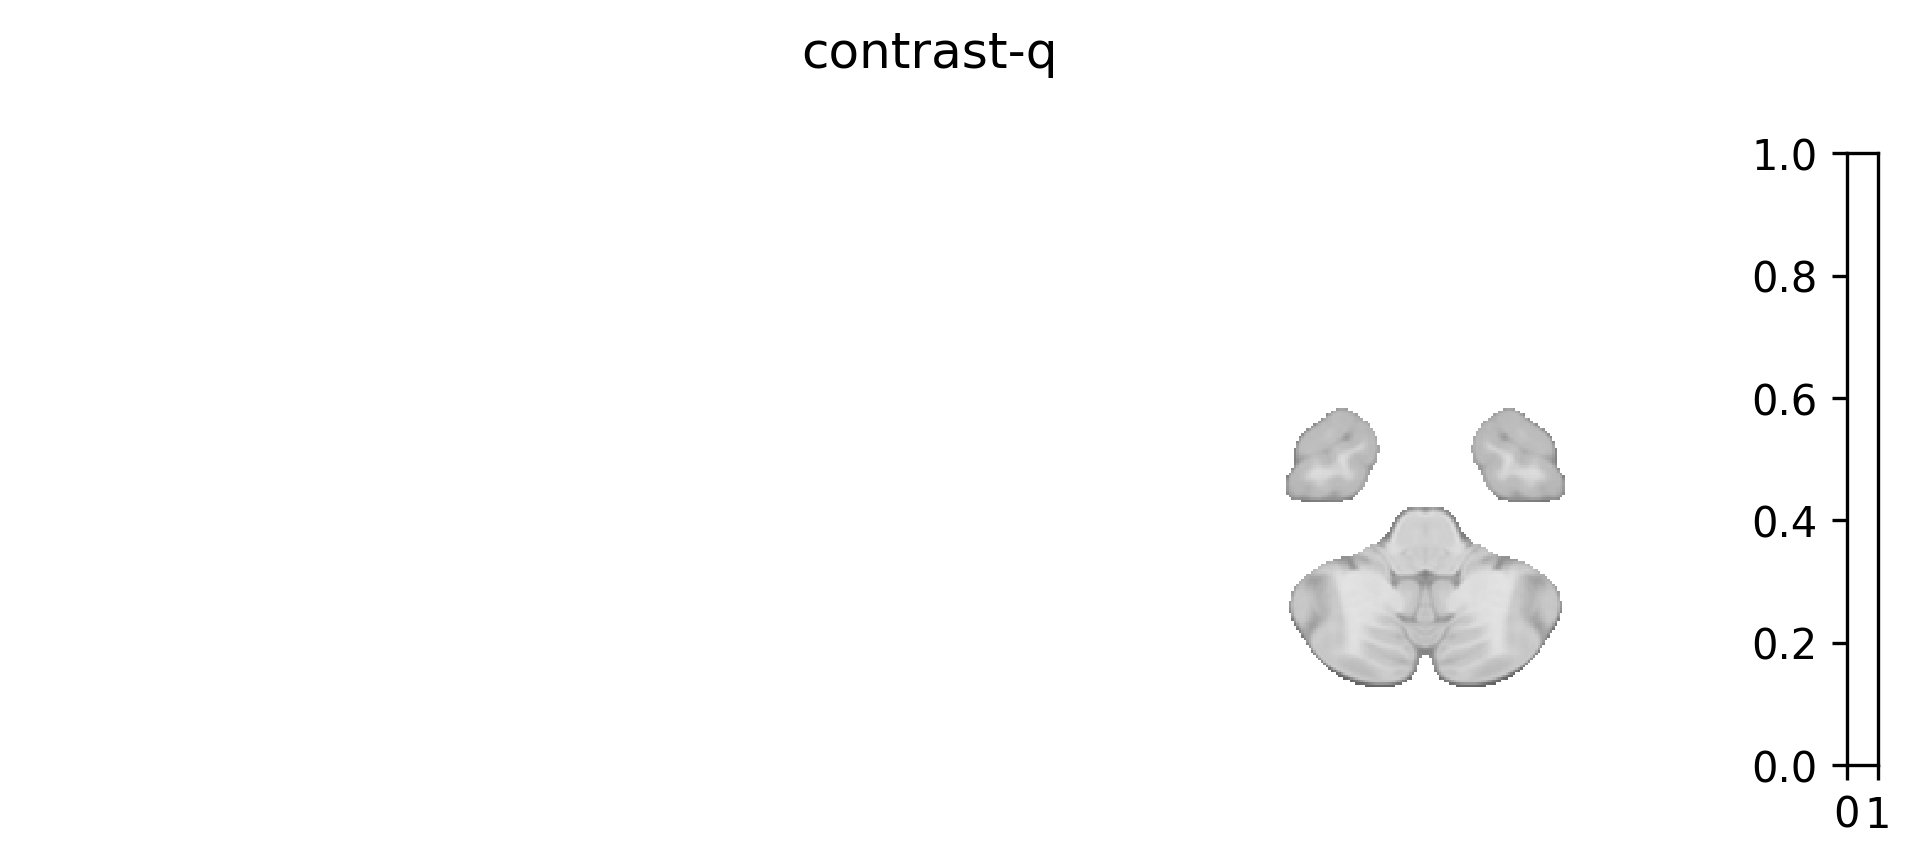

In [47]:
snr_label = 'q'
fig = plot_roi_slices(roi_dict[snr_label], mask_path_list, network_name, space_label, snr_label)

#### Plot for all ROIs and participants

/scratch/slurm-7132610/ipykernel_2456187/1955982139.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


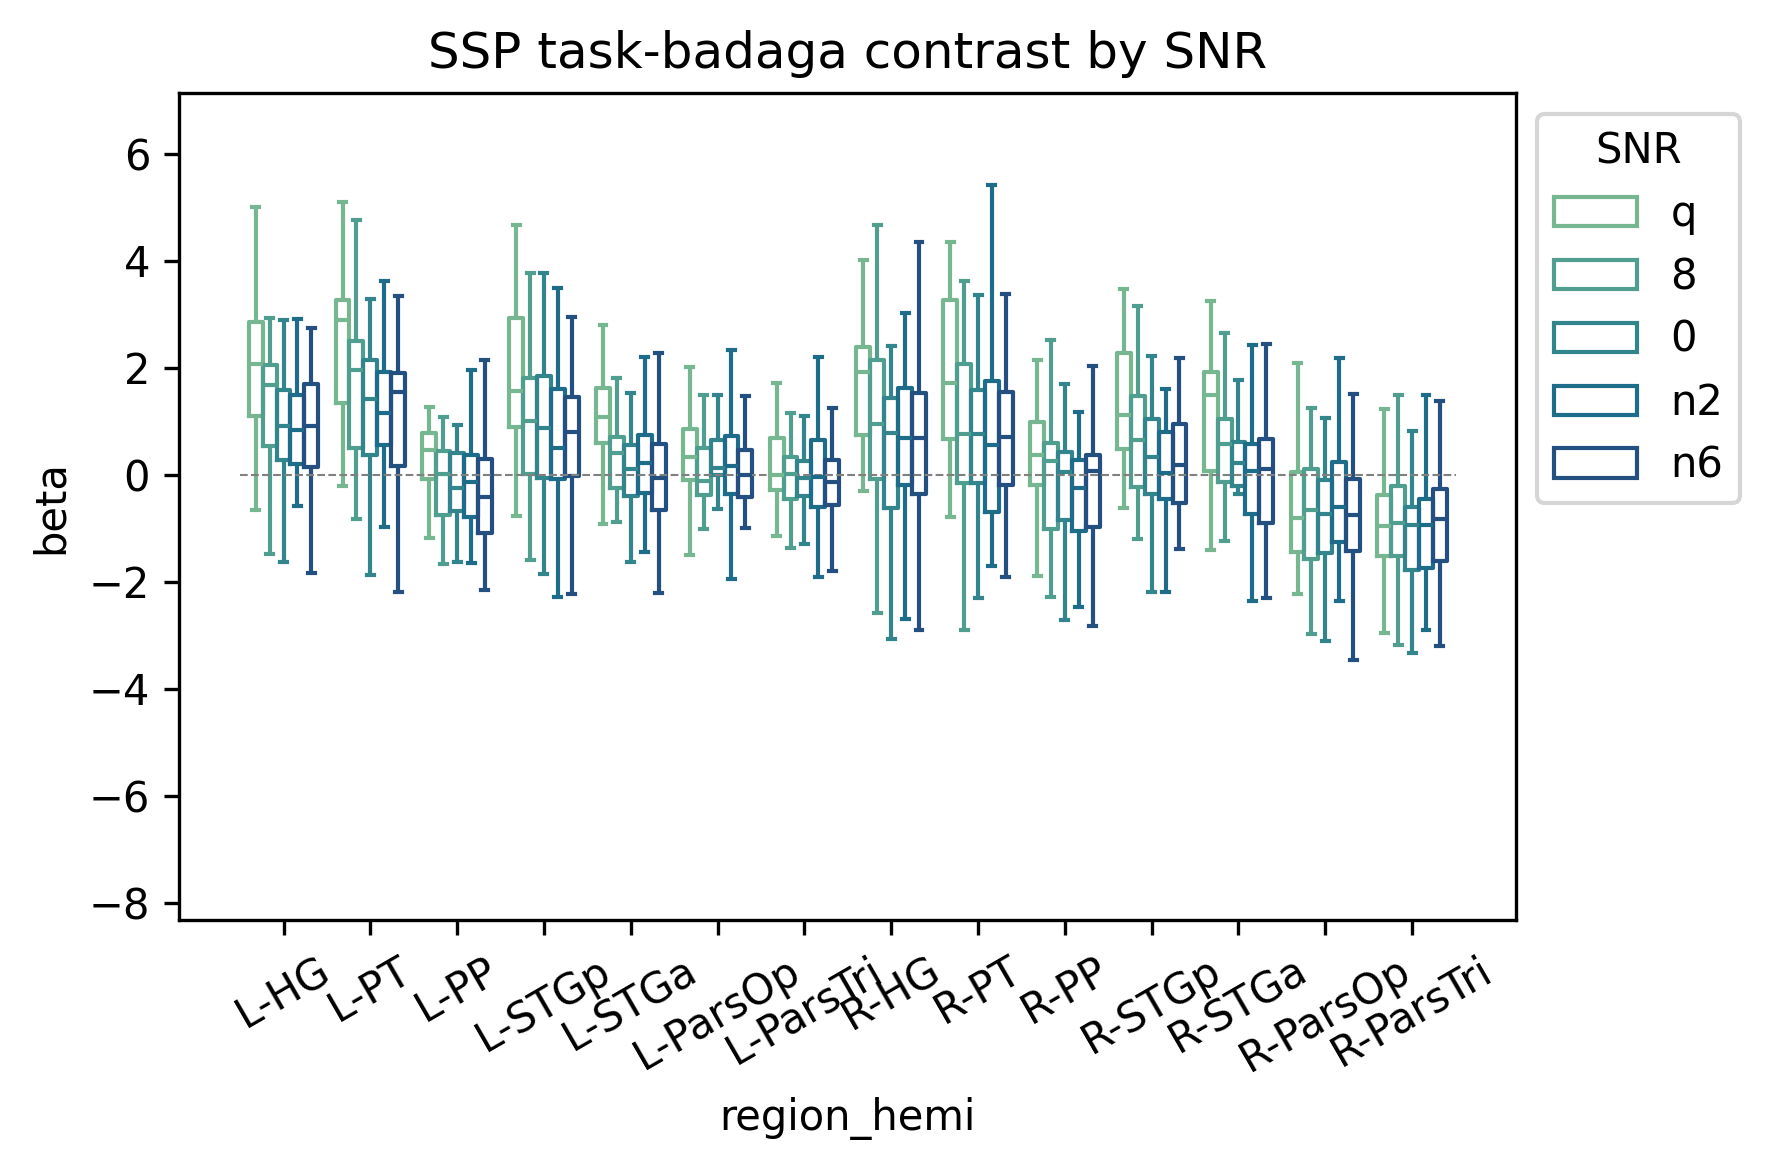

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi", 'SNR'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region_hemi', y='beta', 
              order=region_dict[network_name],
              hue='SNR', hue_order=contrast_list,
              palette='crest',
              fliersize = 0,            
              linewidth=1.,
              fill=False,
              #legend=None,
              ax=ax);
'''
sns.stripplot(data=roi_df_collapsed, 
              x='region_hemi', y='beta', 
              order=region_dict[network_name],
              hue='SNR', hue_order=contrast_list,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.1,
              legend=None,
              ax=ax);
'''

xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'SSP task-badaga contrast by SNR');
#ax.set_ylim([-5, 5])

fig.tight_layout()


### omnibus ANOVA stats

In [51]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(roi_df_long, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'SNR','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)


network: auditory
contrast: n6
                        Anova
                      F Value  Num DF  Den DF  Pr > F
-----------------------------------------------------
hemisphere            10.7383  1.0000  32.0000 0.0025
SNR                   15.9526  4.0000 128.0000 0.0000
region                38.0398  6.0000 192.0000 0.0000
hemisphere:SNR         0.1509  4.0000 128.0000 0.9623
hemisphere:region      7.4131  6.0000 192.0000 0.0000
SNR:region             8.7600 24.0000 768.0000 0.0000
hemisphere:SNR:region  1.4649 24.0000 768.0000 0.0704



/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [66]:
aov.summary().tables[0]

,F Value,Num DF,Den DF,Pr > F
hemisphere,10.7383,1.0000,32.0000,0.0025
SNR,15.9526,4.0000,128.0000,0.0000
region,38.0398,6.0000,192.0000,0.0000
hemisphere:SNR,0.1509,4.0000,128.0000,0.9623
hemisphere:region,7.4131,6.0000,192.0000,0.0000
SNR:region,8.7600,24.0000,768.0000,0.0000
hemisphere:SNR:region,1.4649,24.0000,768.0000,0.0704


In [53]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=roi_df_long,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * region,L,HG,PP,7.365333,32.0,2.237736e-08,1.174811e-07,6.081e+05
1,hemisphere * region,L,HG,PT,-2.656813,32.0,1.220190e-02,1.653161e-02,3.685
2,hemisphere * region,L,HG,ParsOp,3.329523,32.0,2.199984e-03,3.422197e-03,16.12
3,hemisphere * region,L,HG,ParsTri,4.871462,32.0,2.886290e-05,6.734677e-05,787.7
4,hemisphere * region,L,HG,STGa,5.287136,32.0,8.617421e-06,2.129010e-05,2385.611
5,hemisphere * region,L,PP,PT,-8.605822,32.0,7.801078e-10,1.092151e-08,1.44e+07
6,hemisphere * region,L,PP,STGa,-3.296463,32.0,2.401697e-03,3.588108e-03,14.929
7,hemisphere * region,L,PP,STGp,-6.160474,32.0,6.826589e-07,2.538733e-06,2.49e+04
8,hemisphere * region,L,PT,ParsOp,4.850389,32.0,3.068220e-05,6.782381e-05,744.929
9,hemisphere * region,L,PT,ParsTri,6.139453,32.0,7.253523e-07,2.538733e-06,2.354e+04


In [67]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=roi_df_long,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p-unc,p-corr,BF10
0,region * hemisphere,HG,L,R,1.3635,32.0000,0.1822,0.2551,0.433
1,region * hemisphere,PP,L,R,0.4039,32.0000,0.6890,0.6890,0.201
2,region * hemisphere,PT,L,R,2.3851,32.0000,0.0232,0.0405,2.156
3,region * hemisphere,ParsOp,L,R,4.4828,32.0000,0.0001,0.0003,283.512
4,region * hemisphere,ParsTri,L,R,5.9166,32.0000,0.0000,0.0000,1.294e+04
5,region * hemisphere,STGa,L,R,-0.6010,32.0000,0.5521,0.6441,0.22
6,region * hemisphere,STGp,L,R,2.6307,32.0000,0.0130,0.0303,3.493


In [87]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=roi_df_long,
                             dv='beta', 
                             within=['hemisphere','SNR', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * SNR,L,0,8,-1.5723,32.0000,0.1257,0.1895,0.566
1,hemisphere * SNR,L,0,n2,-0.3529,32.0000,0.7264,0.7647,0.197
2,hemisphere * SNR,L,0,n6,0.8951,32.0000,0.3774,0.4718,0.269
3,hemisphere * SNR,L,0,q,-4.3938,32.0000,0.0001,0.0005,224.979
4,hemisphere * SNR,L,8,n2,1.9044,32.0000,0.0659,0.1198,0.927
5,hemisphere * SNR,L,8,n6,3.3921,32.0000,0.0019,0.0037,18.661
6,hemisphere * SNR,L,8,q,-4.8425,32.0000,0.0000,0.0002,729.478
7,hemisphere * SNR,L,n2,n6,1.3029,32.0000,0.2019,0.2692,0.403
8,hemisphere * SNR,L,n2,q,-5.0900,32.0000,0.0000,0.0001,1408.304
9,hemisphere * SNR,L,n6,q,-6.1528,32.0000,0.0000,0.0000,2.44e+04


In [88]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=roi_df_long,
                             dv='beta', 
                             within=['SNR','hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'SNR', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'SNR', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,SNR,A,B,T,dof,p-unc,p-corr,BF10
0,SNR * hemisphere,0,L,R,3.2054,32.0000,0.0031,0.0076,12.108
1,SNR * hemisphere,8,L,R,2.4688,32.0000,0.0191,0.0191,2.532
2,SNR * hemisphere,n2,L,R,3.5644,32.0000,0.0012,0.0058,28.109
3,SNR * hemisphere,n6,L,R,2.5089,32.0000,0.0174,0.0191,2.739
4,SNR * hemisphere,q,L,R,2.8514,32.0000,0.0076,0.0126,5.534


In [89]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=roi_df_long,
                             dv='beta', 
                             within=['SNR', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
3,SNR,SNR,0,q,-4.4906,32.0000,0.0001,0.0002,289.355
5,SNR,SNR,8,n6,4.6591,32.0000,0.0001,0.0001,449.71
6,SNR,SNR,8,q,-4.7802,32.0000,0.0000,0.0001,618.642
8,SNR,SNR,n2,q,-4.7918,32.0000,0.0000,0.0001,638.043
9,SNR,SNR,n6,q,-6.8569,32.0000,0.0000,0.0000,1.596e+05


#### Collapse (average) over non-significant factors

In [58]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

In [59]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi", 'SNR'], 
                                       as_index=False).agg({"beta": "mean"})


In [60]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: L-HG, t = 9.97; corrected p = 0.0000
Region: L-PP, t = -1.52; corrected p = 0.1404
Region: L-PT, t = 12.25; corrected p = 0.0000
Region: L-ParsOp, t = 1.88; corrected p = 0.0788
Region: L-ParsTri, t = -0.22; corrected p = 0.8297
Region: L-STGa, t = 2.73; corrected p = 0.0098
Region: L-STGp, t = 8.48; corrected p = 0.0000
Region: R-HG, t = 6.04; corrected p = 0.0000
Region: R-PP, t = -1.76; corrected p = 0.0934
Region: R-PT, t = 8.05; corrected p = 0.0000
Region: R-ParsOp, t = -7.78; corrected p = 0.0000
Region: R-ParsTri, t = -9.90; corrected p = 0.0000
Region: R-STGa, t = 3.73; corrected p = 0.0004
Region: R-STGp, t = 4.68; corrected p = 0.0000


In [96]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region_hemi",'SNR']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, SNR, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, SNR: {SNR}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: L-HG, SNR: 0, t = 3.77; corrected p = 0.0022
Region: L-HG, SNR: 8, t = 5.84; corrected p = 0.0000
Region: L-HG, SNR: n2, t = 3.61; corrected p = 0.0033
Region: L-HG, SNR: n6, t = 2.81; corrected p = 0.0183
Region: L-HG, SNR: q, t = 7.09; corrected p = 0.0000
Region: L-PP, SNR: 0, t = -2.12; corrected p = 0.0731
Region: L-PP, SNR: 8, t = -0.51; corrected p = 0.6934
Region: L-PP, SNR: n2, t = -0.89; corrected p = 0.4724
Region: L-PP, SNR: n6, t = -2.05; corrected p = 0.0830
Region: L-PP, SNR: q, t = 2.88; corrected p = 0.0168
Region: L-PT, SNR: 0, t = 4.53; corrected p = 0.0004
Region: L-PT, SNR: 8, t = 5.74; corrected p = 0.0000
Region: L-PT, SNR: n2, t = 4.39; corrected p = 0.0005
Region: L-PT, SNR: n6, t = 4.85; corrected p = 0.0002
Region: L-PT, SNR: q, t = 8.80; corrected p = 0.0000
Region: L-ParsOp, SNR: 0, t = 0.65; corrected p = 0.6170
Region: L-ParsOp, SNR: 8, t = 0.31; corrected p = 0.8179
Region: L-ParsOp, SNR: n2, t = 0.94; corrected p = 0.4660
Region: L-ParsOp, SNR: 

In [91]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region_hemi",'SNR']):
    #print(region_stage)
    if region_stage[1] == 'q':
        t_stat, p_val = ttest_1samp(data["beta"], 0)
        p_values.append(p_val)
        comparisons.append((region_stage[0], region_stage[1], t_stat))
        t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, SNR, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, SNR: {SNR}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: L-HG, SNR: q, t = 7.09; corrected p = 0.0000
Region: L-PP, SNR: q, t = 2.88; corrected p = 0.0089
Region: L-PT, SNR: q, t = 8.80; corrected p = 0.0000
Region: L-ParsOp, SNR: q, t = 2.56; corrected p = 0.0181
Region: L-ParsTri, SNR: q, t = 1.23; corrected p = 0.2287
Region: L-STGa, SNR: q, t = 5.01; corrected p = 0.0000
Region: L-STGp, SNR: q, t = 7.27; corrected p = 0.0000
Region: R-HG, SNR: q, t = 6.17; corrected p = 0.0000
Region: R-PP, SNR: q, t = 1.69; corrected p = 0.1083
Region: R-PT, SNR: q, t = 7.36; corrected p = 0.0000
Region: R-ParsOp, SNR: q, t = -3.01; corrected p = 0.0071
Region: R-ParsTri, SNR: q, t = -3.22; corrected p = 0.0046
Region: R-STGa, SNR: q, t = 5.67; corrected p = 0.0000
Region: R-STGp, SNR: q, t = 7.13; corrected p = 0.0000


In [95]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby("region_hemi"):
    # pivot to get one column per SNR
    wide = data.pivot(index="participant_id", columns="SNR", values="beta")

    # drop subjects missing one condition
    wide = wide.dropna(subset=["q", "n6"])

    t_stat, p_val = ttest_rel(wide["q"], wide["n6"])

    p_values.append(p_val)
    t_stats.append(t_stat)
    comparisons.append(region)

# FDR correction
_, p_corrected, _, _ = multipletests(p_values, method="fdr_bh")

# Print results
for region, t_stat, p_corr in zip(comparisons, t_stats, p_corrected):
    print(f"{region}, q vs n6, t = {t_stat:.2f}, corrected p = {p_corr:.4f}")


L-HG, q vs n6, t = 6.30, corrected p = 0.0000
L-PP, q vs n6, t = 4.03, corrected p = 0.0005
L-PT, q vs n6, t = 7.09, corrected p = 0.0000
L-ParsOp, q vs n6, t = 2.63, corrected p = 0.0166
L-ParsTri, q vs n6, t = 1.86, corrected p = 0.0781
L-STGa, q vs n6, t = 7.22, corrected p = 0.0000
L-STGp, q vs n6, t = 7.27, corrected p = 0.0000
R-HG, q vs n6, t = 4.58, corrected p = 0.0001
R-PP, q vs n6, t = 4.37, corrected p = 0.0002
R-PT, q vs n6, t = 6.31, corrected p = 0.0000
R-ParsOp, q vs n6, t = 1.92, corrected p = 0.0737
R-ParsTri, q vs n6, t = 1.25, corrected p = 0.2203
R-STGa, q vs n6, t = 8.75, corrected p = 0.0000
R-STGp, q vs n6, t = 6.21, corrected p = 0.0000
